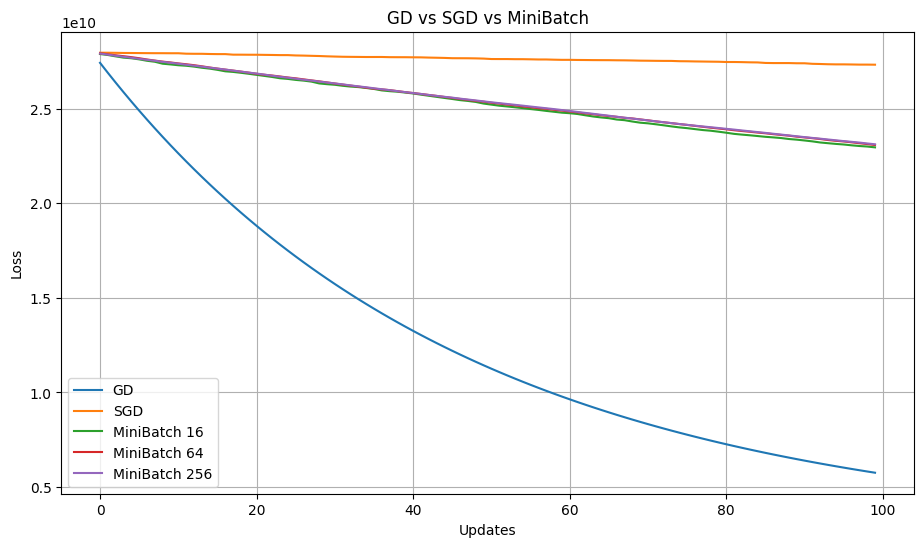


Final losses
GD: 5756437577.821843
SGD: 27329698776.81284
MiniBatch 16: 22959415487.580105
MiniBatch 64: 23082480018.60121
MiniBatch 256: 23121116197.23044

Test MSE
GD MSE=11,976,394,424.50
SGD MSE=55,550,233,695.27
MiniBatch 16 MSE=46,738,817,345.98
MiniBatch 64 MSE=47,003,716,827.49
MiniBatch 256 MSE=47,085,143,915.51


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# ======================
# Load data
# ======================
df = pd.read_csv("../datasets/housing.csv")

df = pd.get_dummies(
    df,
    columns=['ocean_proximity']
)

df = df.dropna()

X = df.drop(
    "median_house_value",
    axis=1
).values

y = df[
    "median_house_value"
].values.reshape(-1,1)


# scale
scaler = StandardScaler()
X = scaler.fit_transform(X)

X=np.c_[
    np.ones((X.shape[0],1)),
    X
]

X_train,X_test,y_train,y_test= train_test_split(
    X,y,
    test_size=0.2,
    random_state=42
)

m=len(X_train)
n=X.shape[1]

# learning rates riêng
lr_gd=0.01
lr_sgd=0.0001
lr_mb=0.001

epochs=100

def loss(X,y,theta):
    return (1/(2*len(X))) * np.sum(
        (X@theta-y)**2
    )

def evaluate(theta,name):
    pred=X_test@theta

    # tránh inf nan
    pred=np.nan_to_num(
        pred
    )

    mse=mean_squared_error(
        y_test,
        pred
    )

    print(
        f"{name} MSE={mse:,.2f}"
    )


# ======================
# Batch GD
# ======================
theta_gd=np.zeros((n,1))
loss_gd=[]

for _ in range(epochs):

    grad=(1/m)*X_train.T@(
        X_train@theta_gd-y_train
    )

    theta_gd-=lr_gd*grad

    loss_gd.append(
        loss(
            X_train,
            y_train,
            theta_gd
        )
    )


# ======================
# SGD
# ======================
theta_sgd=np.zeros((n,1))
loss_sgd=[]

for _ in range(epochs):

    i=np.random.randint(m)

    xi=X_train[i:i+1]
    yi=y_train[i:i+1]

    grad=xi.T@(
        xi@theta_sgd-yi
    )

    theta_sgd-=lr_sgd*grad

    loss_sgd.append(
        loss(
            X_train,
            y_train,
            theta_sgd
        )
    )


# ======================
# Mini Batch
# ======================
batch_sizes=[16,64,256]

mb_losses={}
mb_thetas={}

for b in batch_sizes:

    theta=np.zeros((n,1))

    losses=[]

    for _ in range(epochs):

        idx=np.random.choice(
            m,
            b,
            replace=False
        )

        xb=X_train[idx]
        yb=y_train[idx]

        grad=(1/b)*xb.T@(
            xb@theta-yb
        )

        theta-=lr_mb*grad

        losses.append(
            loss(
                X_train,
                y_train,
                theta
            )
        )

    mb_losses[b]=losses
    mb_thetas[b]=theta


# ======================
# Plot
# ======================
plt.figure(figsize=(11,6))

plt.plot(
    loss_gd,
    label="GD"
)

plt.plot(
    loss_sgd,
    label="SGD"
)

for b in batch_sizes:
    plt.plot(
        mb_losses[b],
        label=f"MiniBatch {b}"
    )

plt.xlabel("Updates")
plt.ylabel("Loss")
plt.title(
"GD vs SGD vs MiniBatch"
)
plt.legend()
plt.grid()
plt.show()


# ======================
# Results
# ======================
print("\nFinal losses")
print(
"GD:",
loss_gd[-1]
)
print(
"SGD:",
loss_sgd[-1]
)

for b in batch_sizes:
    print(
f"MiniBatch {b}:",
mb_losses[b][-1]
)

print("\nTest MSE")
evaluate(
    theta_gd,
    "GD"
)
evaluate(
    theta_sgd,
    "SGD"
)

for b in batch_sizes:
    evaluate(
        mb_thetas[b],
        f"MiniBatch {b}"
    )

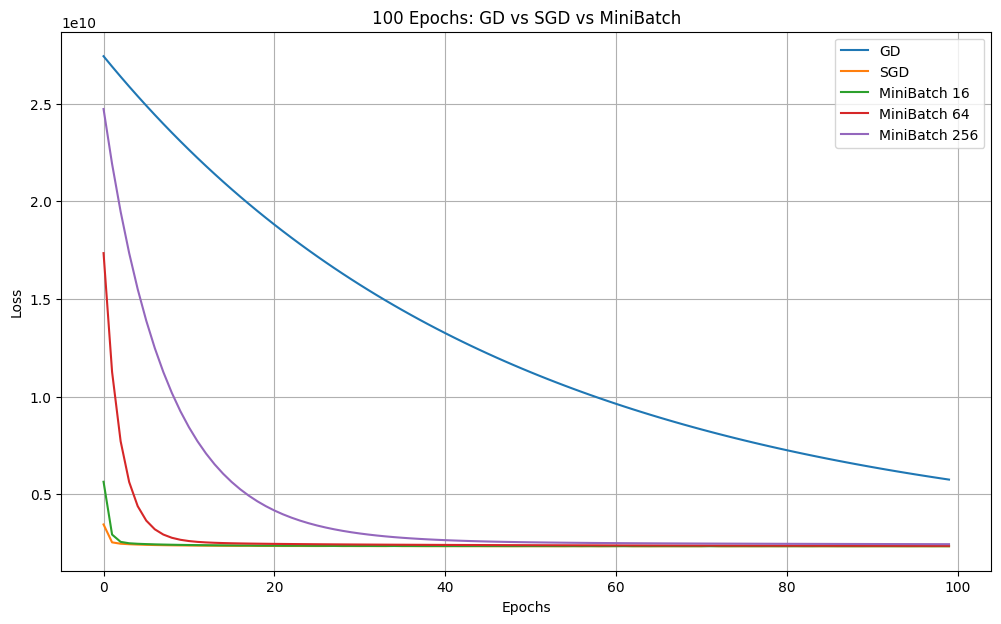


Test MSE
GD: 11,976,394,424.50
SGD: 4,806,314,800.76
MiniBatch 16: 4,799,774,005.71
MiniBatch 64: 4,841,918,229.65
MiniBatch 256: 5,045,047,294.62


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# =========================
# 1. LOAD DATA
# =========================
df = pd.read_csv("../datasets/housing.csv")

df = pd.get_dummies(
    df,
    columns=["ocean_proximity"]
)

df = df.dropna()

X = df.drop(
    "median_house_value",
    axis=1
).values

y = df[
 "median_house_value"
].values.reshape(-1,1)

# chuẩn hóa
scaler=StandardScaler()
X=scaler.fit_transform(X)

# bias
X=np.c_[
    np.ones((X.shape[0],1)),
    X
]

X_train,X_test,y_train,y_test=train_test_split(
    X,y,
    test_size=0.2,
    random_state=42
)

m,n=X_train.shape

# =========================
# Config
# =========================
epochs=100

lr_gd=0.01
lr_sgd=0.0001
lr_mb=0.001

batch_sizes=[16,64,256]

def loss(X,y,theta):
    return np.mean(
      (X@theta-y)**2
    )/2

def evaluate(theta,name):
    pred=X_test@theta
    mse=mean_squared_error(
        y_test,pred
    )
    print(
        f"{name}: {mse:,.2f}"
    )


# =========================
# 2. Batch GD
# =========================
theta_gd=np.zeros((n,1))
loss_gd=[]

for epoch in range(epochs):

    grad=(1/m)*X_train.T@(
        X_train@theta_gd-y_train
    )

    theta_gd-=lr_gd*grad

    loss_gd.append(
        loss(
         X_train,
         y_train,
         theta_gd
        )
    )


# =========================
# 3. SGD (100 epochs)
# =========================
theta_sgd=np.zeros((n,1))
loss_sgd=[]

for epoch in range(epochs):

    idx=np.random.permutation(m)

    for i in idx:

        xi=X_train[i:i+1]
        yi=y_train[i:i+1]

        grad=xi.T@(
          xi@theta_sgd-yi
        )

        theta_sgd-=lr_sgd*grad

    loss_sgd.append(
        loss(
         X_train,
         y_train,
         theta_sgd
        )
    )


# =========================
# 4. Mini Batch
# =========================
mb_losses={}
mb_thetas={}

for b in batch_sizes:

    theta=np.zeros((n,1))
    losses=[]

    for epoch in range(epochs):

        idx=np.random.permutation(m)

        Xs=X_train[idx]
        ys=y_train[idx]

        for i in range(
            0,
            m,
            b
        ):

            xb=Xs[i:i+b]
            yb=ys[i:i+b]

            grad=(1/len(xb))*xb.T@(
                xb@theta-yb
            )

            theta-=lr_mb*grad


        losses.append(
            loss(
                X_train,
                y_train,
                theta
            )
        )

    mb_losses[b]=losses
    mb_thetas[b]=theta


# =========================
# 5. Plot
# =========================
plt.figure(
 figsize=(12,7)
)

plt.plot(
 loss_gd,
 label="GD"
)

plt.plot(
 loss_sgd,
 label="SGD"
)

for b in batch_sizes:
    plt.plot(
      mb_losses[b],
      label=f"MiniBatch {b}"
    )

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title(
"100 Epochs: GD vs SGD vs MiniBatch"
)
plt.legend()
plt.grid()
plt.show()


# =========================
# 6. Test Error
# =========================
print("\nTest MSE")
evaluate(
 theta_gd,
 "GD"
)

evaluate(
 theta_sgd,
 "SGD"
)

for b in batch_sizes:
    evaluate(
      mb_thetas[b],
      f"MiniBatch {b}"
    )